In [1]:
import sys
sys.path.append('..')  # lets us import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data, get_feature_target_split

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

In [2]:
# Cell 2 — Load data
df = load_raw_data('C:/p/data/raw/Telco_customer_churn.xlsx')


[data_loader] Dataset loaded: 7043 rows, 33 columns
[data_loader] Columns: ['customerid', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason']


In [3]:
print("Shape:", df.shape)
print(f"\nTotal rows: {df.shape[0]}, Total columns: {df.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Shape: (7043, 33)

Total rows: 7043, Total columns: 33

All columns:
   1. customerid
   2. count
   3. country
   4. state
   5. city
   6. zip_code
   7. lat_long
   8. latitude
   9. longitude
  10. gender
  11. senior_citizen
  12. partner
  13. dependents
  14. tenure_months
  15. phone_service
  16. multiple_lines
  17. internet_service
  18. online_security
  19. online_backup
  20. device_protection
  21. tech_support
  22. streaming_tv
  23. streaming_movies
  24. contract
  25. paperless_billing
  26. payment_method
  27. monthly_charges
  28. total_charges
  29. churn_label
  30. churn_value
  31. churn_score
  32. cltv
  33. churn_reason


In [4]:
# Cell 4 — Data types and non-null counts
# This tells us: which columns are numeric vs text, and if any data is missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_service   7043 

In [5]:
# Cell 5 — Summary statistics for numeric columns
# count, mean, std, min, 25th percentile, median, 75th percentile, max
df.describe()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,churn_value,churn_score,cltv
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).query('missing_count > 0')

if missing_df.empty:
    print("No missing values found!")
else:
    print("Columns with missing values:")
    print(missing_df)

Columns with missing values:
              missing_count  missing_percent
churn_reason           5174            73.46


In [7]:
# Our target is 'churn_label' — contains 'Yes' or 'No'
print("Target column: churn_label")
print("\nValue counts:")
print(df['churn_label'].value_counts())

print("\nChurn rate (proportion):")
print(df['churn_label'].value_counts(normalize=True).round(3))

Target column: churn_label

Value counts:
churn_label
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (proportion):
churn_label
No     0.735
Yes    0.265
Name: proportion, dtype: float64


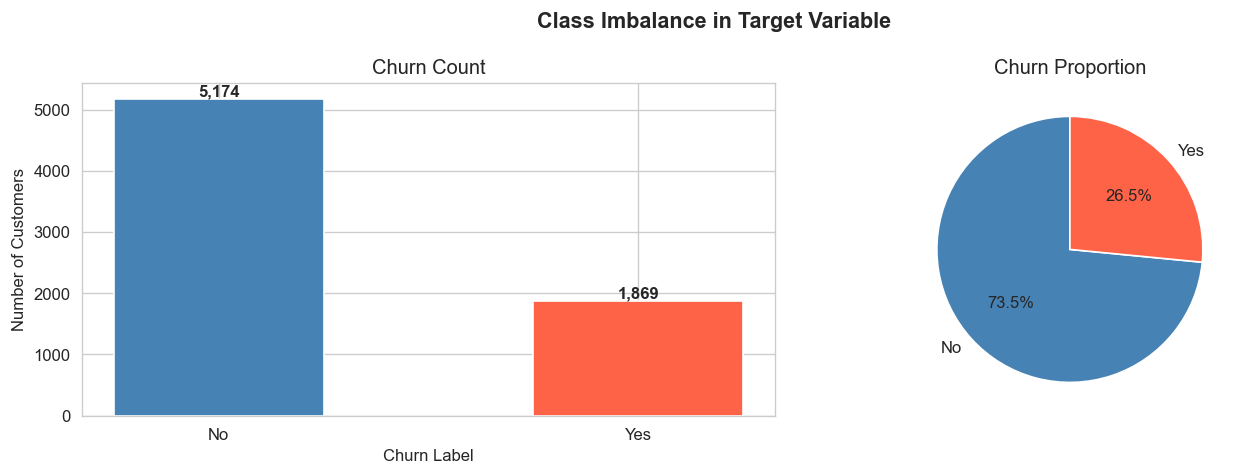


Imbalance ratio: 2.8:1 (No:Yes)


In [8]:
# This chart shows how many customers churned vs didn't
# Class imbalance means one class has far more samples than the other
# A naive model could just always predict 'No' and get ~73% accuracy
# That's why we need SMOTE later — to balance the classes during training

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['churn_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], width=0.5)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn Label')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Churn Proportion')

plt.suptitle('Class Imbalance in Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=150)
plt.show()

print(f"\nImbalance ratio: {counts['No']/counts['Yes']:.1f}:1 (No:Yes)")

In [9]:
# total_charges should be a number but may have been loaded as text
# This is a known issue in this dataset
print("total_charges dtype:", df['total_charges'].dtype)
print("\nSample values:")
print(df['total_charges'].head(10).tolist())

# Check for blank or space-only entries
if df['total_charges'].dtype == object:
    blanks = df[df['total_charges'].astype(str).str.strip() == '']
    print(f"\nBlank total_charges rows: {len(blanks)}")
    if len(blanks) > 0:
        print(blanks[['customerid', 'tenure_months', 'monthly_charges', 'total_charges']])
else:
    print("\ntotal_charges is already numeric — no issue!")

total_charges dtype: object

Sample values:
[108.15, 151.65, 820.5, 3046.05, 5036.3, 528.35, 39.65, 20.15, 4749.15, 30.2]

Blank total_charges rows: 11
      customerid  tenure_months  monthly_charges total_charges
2234  4472-LVYGI              0            52.55              
2438  3115-CZMZD              0            20.25              
2568  5709-LVOEQ              0            80.85              
2667  4367-NUYAO              0            25.75              
2856  1371-DWPAZ              0            56.05              
4331  7644-OMVMY              0            19.85              
4687  3213-VVOLG              0            25.35              
5104  2520-SGTTA              0            20.00              
5719  2923-ARZLG              0            19.70              
6772  4075-WKNIU              0            73.35              
6840  2775-SEFEE              0            61.90              


In [10]:
# Separate columns by type — we'll treat them differently in Phase 2

# These columns are geolocation — we'll drop them (not useful for ML)
geo_cols = ['city', 'zip_code', 'latitude', 'longitude', 'lat_long']

# These are numeric columns the model will use directly
numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']

# These are text columns that need to be converted to numbers (encoding)
categorical_cols = [
    'gender', 'senior_citizen', 'partner', 'dependents',
    'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'contract', 'paperless_billing', 'payment_method'
]

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)
print("\nGeo columns (will be dropped):", geo_cols)
print("\nTarget: churn_label")
print("\nDropped (data leakage): churn_value, churn_score, churn_reason, cltv")

Numeric columns: ['tenure_months', 'monthly_charges', 'total_charges']

Categorical columns: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

Geo columns (will be dropped): ['city', 'zip_code', 'latitude', 'longitude', 'lat_long']

Target: churn_label

Dropped (data leakage): churn_value, churn_score, churn_reason, cltv


In [11]:
# See what unique values each categorical column has
# This tells us how many categories we need to encode
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} values): {sorted([str(v) for v in unique_vals])}")

gender (2 values): ['Female', 'Male']
senior_citizen (2 values): ['No', 'Yes']
partner (2 values): ['No', 'Yes']
dependents (2 values): ['No', 'Yes']
phone_service (2 values): ['No', 'Yes']
multiple_lines (3 values): ['No', 'No phone service', 'Yes']
internet_service (3 values): ['DSL', 'Fiber optic', 'No']
online_security (3 values): ['No', 'No internet service', 'Yes']
online_backup (3 values): ['No', 'No internet service', 'Yes']
device_protection (3 values): ['No', 'No internet service', 'Yes']
tech_support (3 values): ['No', 'No internet service', 'Yes']
streaming_tv (3 values): ['No', 'No internet service', 'Yes']
streaming_movies (3 values): ['No', 'No internet service', 'Yes']
contract (3 values): ['Month-to-month', 'One year', 'Two year']
paperless_billing (2 values): ['No', 'Yes']
payment_method (4 values): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


In [12]:
# Fix: convert total_charges from text to number
# errors='coerce' means: if a value can't be converted (like a blank space),
# replace it with NaN (Not a Number) instead of crashing

df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Fill the NaN values with 0 (these are new customers with no charges yet)
df['total_charges'] = df['total_charges'].fillna(0)

# Confirm it worked
print("total_charges dtype is now:", df['total_charges'].dtype)
print("Any remaining nulls:", df['total_charges'].isnull().sum())

total_charges dtype is now: float64
Any remaining nulls: 0


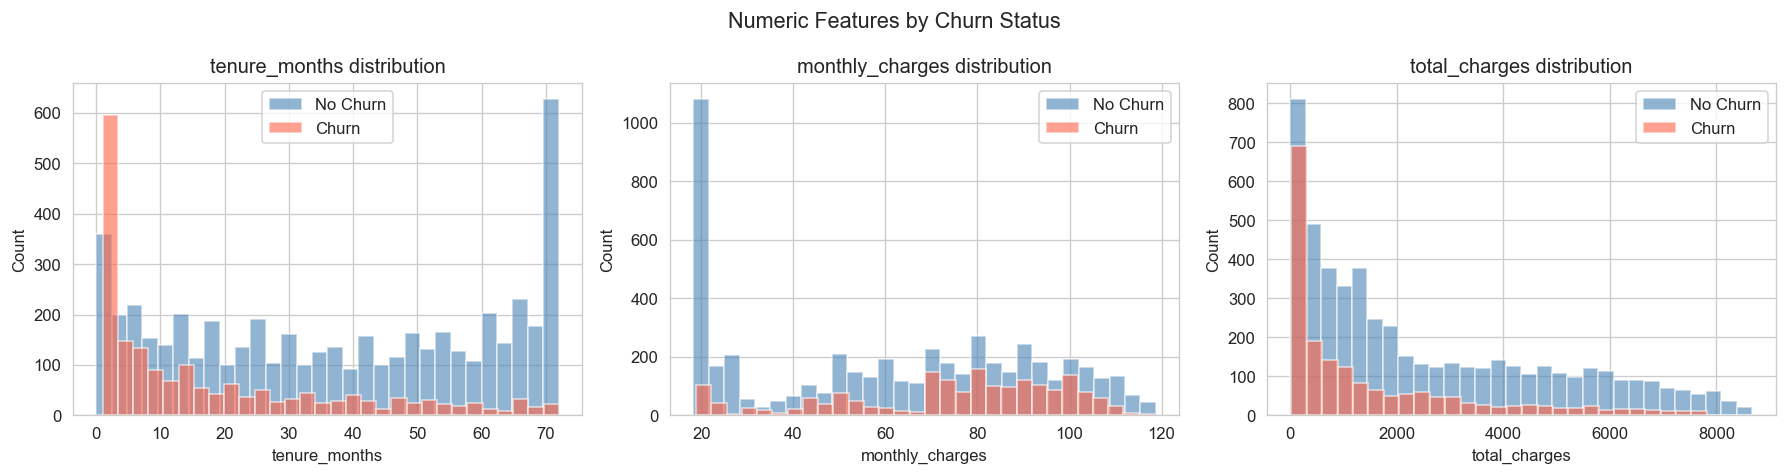

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    # Plot distribution separately for churned vs not-churned customers
    # This shows which values are associated with higher churn
    df[df['churn_label'] == 'No'][col].hist(
        bins=30, ax=ax, alpha=0.6, color='steelblue', label='No Churn'
    )
    df[df['churn_label'] == 'Yes'][col].hist(
        bins=30, ax=ax, alpha=0.6, color='tomato', label='Churn'
    )
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Features by Churn Status', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/numeric_distributions.png', dpi=150)
plt.show()


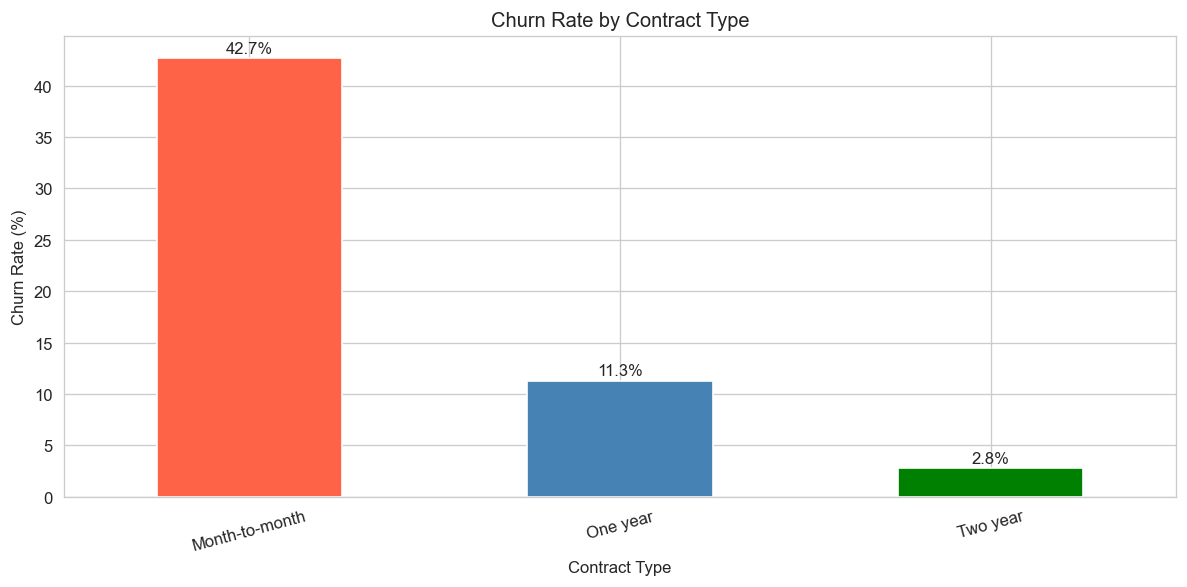

         contract  churn_rate_pct
0  Month-to-month            42.7
1        One year            11.3
2        Two year             2.8


In [14]:
# Contract type is one of the strongest predictors of churn
# Month-to-month customers churn far more than those on 1-2 year contracts

contract_churn = df.groupby('contract')['churn_label'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
contract_churn.columns = ['contract', 'churn_rate_pct']

ax = contract_churn.plot(
    kind='bar', x='contract', y='churn_rate_pct',
    color=['tomato', 'steelblue', 'green'], legend=False
)
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5), 
                ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_contract.png', dpi=150)
plt.show()
print(contract_churn)

In [15]:
# This uses the function we wrote in data_loader.py
# X = all feature columns (what the model learns from)
# y = target column (what the model predicts)
X, y = get_feature_target_split(df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny unique values:", y.unique())
print("\nX column list:")
print(X.columns.tolist())

[data_loader] Features shape: (7043, 19)
[data_loader] Target shape: (7043,)
[data_loader] Feature columns: ['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']
X shape: (7043, 19)
y shape: (7043,)

y unique values: ['Yes' 'No']

X column list:
['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']


In [16]:
# Test our features.py module
import sys
sys.path.append('..')
from src.features import engineer_features, encode_binary_columns, NUMERIC_COLS, BINARY_COLS, MULTI_CAT_COLS

# Apply feature engineering to see the new columns
df_engineered = engineer_features(df)

print("New columns added:")
print(df_engineered[['tenure_months', 'charges_per_month', 'tenure_group', 'tenure_group_encoded']].head(10))

[features] Engineered features added: charges_per_month, tenure_group, tenure_group_encoded
[features] New shape: (7043, 36)
New columns added:
   tenure_months  charges_per_month tenure_group tenure_group_encoded
0              2              54.08          new                    0
1              2              75.82          new                    0
2              8             102.56          new                    0
3             28             108.79  established                    2
4             49             102.78        loyal                    3
5             10              52.84          new                    0
6              1              39.65          new                    0
7              1              20.15          new                    0
8             47             101.05  established                    2
9              1              30.20          new                    0


In [17]:
from src.features import prepare_X_y

X_ready, y_ready = prepare_X_y(df)

print("\nX dtypes:")
print(X_ready.dtypes)

print("\nAny nulls in X?", X_ready.isnull().sum().sum())
print("Any nulls in y?", y_ready.isnull().sum())

[features] Engineered features added: charges_per_month, tenure_group, tenure_group_encoded
[features] New shape: (7043, 36)
[features] Binary columns encoded: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'paperless_billing']

[features] Final X shape: (7043, 21)
[features] Final y shape: (7043,)
[features] y distribution: {0: 5174, 1: 1869}
[features] X columns: ['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'charges_per_month', 'tenure_group_encoded']

X dtypes:
gender                     int64
senior_citizen             int64
partner                    int64
dependents                 int64
tenure_months              int64
phone_service              int64
multiple_lines            object

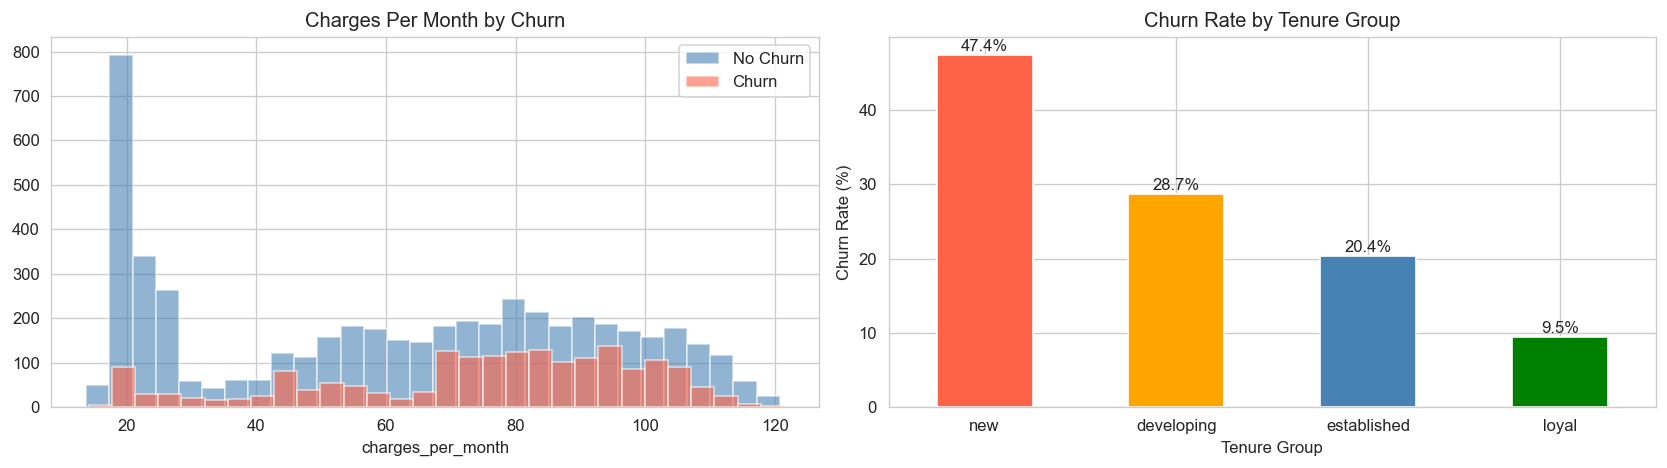

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# charges_per_month by churn
df_engineered[df_engineered['churn_label'] == 'No']['charges_per_month'].hist(
    bins=30, ax=axes[0], alpha=0.6, color='steelblue', label='No Churn')
df_engineered[df_engineered['churn_label'] == 'Yes']['charges_per_month'].hist(
    bins=30, ax=axes[0], alpha=0.6, color='tomato', label='Churn')
axes[0].set_title('Charges Per Month by Churn')
axes[0].set_xlabel('charges_per_month')
axes[0].legend()

# tenure_group by churn rate
tenure_churn = df_engineered.groupby('tenure_group', observed=True)['churn_label'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1)
tenure_churn.plot(kind='bar', ax=axes[1], color=['tomato','orange','steelblue','green'])
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5), ha='center')

plt.tight_layout()
plt.savefig('../reports/figures/engineered_features.png', dpi=150)
plt.show()